<a href="https://colab.research.google.com/github/AlexBronte/mentor/blob/master/%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D1%8C%D1%8F_%D0%B8_%D0%B0%D0%BD%D1%81%D0%B0%D0%BC%D0%B1%D0%BB%D0%B8_%22hw_trees_ensembles_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: Деревья и ансамбли
В этом задании вы примените **деревья решений, случайный лес и бустинг** для решения реальной классификации.
Мы будем работать с датасетом о предсказании оттока клиентов банка.

In [290]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay


## 1. Загрузка и первичный обзор данных

## 📑 Описание признаков датасета Telco Customer Churn

1. **gender** – пол клиента (`Male` или `Female`).  
2. **SeniorCitizen** – является ли клиент пожилым человеком (`1` – да, `0` – нет).  
3. **Partner** – есть ли у клиента супруг/супруга (`Yes` или `No`).  
4. **Dependents** – есть ли иждивенцы (дети, родственники) (`Yes` или `No`).  
5. **tenure** – срок обслуживания в компании (количество месяцев).  
6. **PhoneService** – подключена ли телефонная линия (`Yes` или `No`).  
7. **MultipleLines** – наличие нескольких телефонных линий (`No`, `Yes`, `No phone service`).  
8. **InternetService** – тип интернет-сервиса (`DSL`, `Fiber optic`, `No`).  
9. **OnlineSecurity** – наличие услуги онлайн-безопасности (`Yes`, `No`, `No internet service`).  
10. **OnlineBackup** – наличие услуги онлайн-бэкапа данных (`Yes`, `No`, `No internet service`).  
11. **DeviceProtection** – наличие услуги защиты устройства (`Yes`, `No`, `No internet service`).  
12. **TechSupport** – наличие услуги технической поддержки (`Yes`, `No`, `No internet service`).  
13. **StreamingTV** – наличие услуги потокового ТВ (`Yes`, `No`, `No internet service`).  
14. **StreamingMovies** – наличие услуги потокового кино (`Yes`, `No`, `No internet service`).  
15. **Contract** – тип контракта (`Month-to-month`, `One year`, `Two year`).  
16. **PaperlessBilling** – используется ли безбумажная оплата (`Yes` или `No`).  
17. **PaymentMethod** – метод оплаты (`Electronic check`, `Mailed check`, `Bank transfer (automatic)`, `Credit card (automatic)`).  
18. **MonthlyCharges** – ежемесячные расходы клиента (в долларах).  
19. **TotalCharges** – общая сумма расходов клиента за всё время (в долларах).  
20. **Churn** – целевая переменная: ушёл ли клиент (`Yes` – ушёл, `No` – остался).  


In [291]:
# Данные возьмем из открытого источника (Churn dataset)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Посмотрим на данные
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. EDA (разведочный анализ данных)
- Посмотрите на размеры датасета
- Проверьте наличие пропусков. Если есть пропуски, заполните их
- Посчитайте распределение целевой переменной (`Churn`)

In [292]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


В данных **нет пропусков** , всего 7043 объекта и 20 признаков

In [293]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [294]:
df.duplicated().sum()

np.int64(0)

Также в данных **отсутствуют дубликаты**

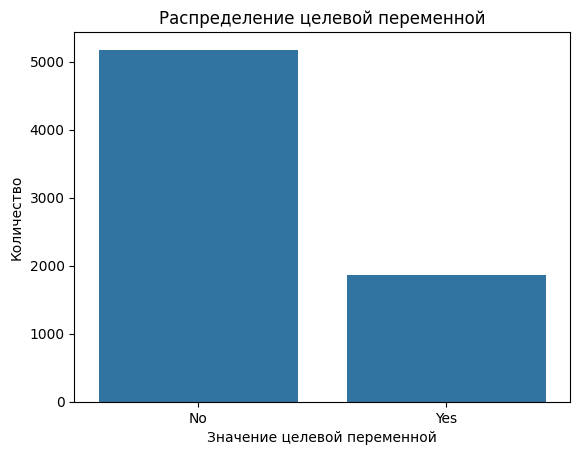

In [295]:
target_counts = df['Churn'].value_counts()

sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title("Распределение целевой переменной")
plt.xlabel("Значение целевой переменной")
plt.ylabel("Количество")
plt.show()

In [296]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


По целевым данным заметен **явный дисбаланс-73% клиентов остались а 26% ушли**

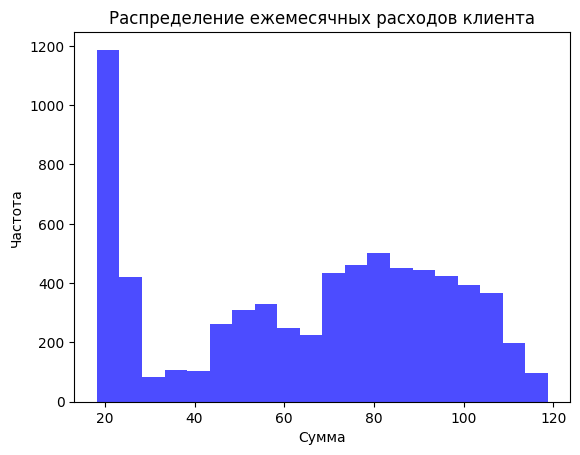

In [297]:
plt.hist(df['MonthlyCharges'],bins=20, color='blue', alpha=0.7)
plt.title('Распределение ежемесячных расходов клиента')
plt.xlabel('Сумма')
plt.ylabel('Частота')
plt.show()

На графике видно что **большая** часть клиентов **расходует около 20$ в месяц**

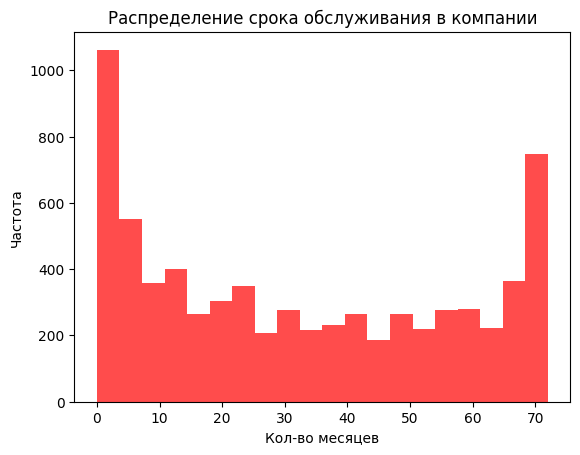

In [298]:
plt.hist(df['tenure'],bins=20, color='red', alpha=0.7)
plt.title('Распределение срока обслуживания в компании')
plt.xlabel('Кол-во месяцев')
plt.ylabel('Частота')
plt.show()

По данным видно что **пик обслуживания** приходится на **первые** и **последние** месяца

## 3. Предобработка данных
Разделите выборку на train/test части

In [299]:
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_2291/372009398.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})


In [300]:
df['TotalCharges']=pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [301]:
X = df.drop(columns=['Churn','customerID'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42) # YOUR CODE HERE
X_train.shape, X_test.shape

((5634, 19), (1409, 19))

In [302]:
ohe_cols = []
numeric_cols = []

for col in X.columns:
  if df[col].dtype == 'object':
    ohe_cols.append(col)
  else:
    numeric_cols.append(col)


In [303]:
numeric_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [304]:
ohe_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [305]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols),
    ('numeric', 'passthrough', numeric_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [306]:
X_train_processed

array([[1.00000e+00, 0.00000e+00, 1.00000e+00, ..., 2.10000e+01,
        6.48500e+01, 1.33680e+03],
       [1.00000e+00, 0.00000e+00, 1.00000e+00, ..., 5.40000e+01,
        9.72000e+01, 5.12945e+03],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        2.34500e+01, 2.34500e+01],
       ...,
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.20000e+01,
        2.11500e+01, 3.06050e+02],
       [0.00000e+00, 1.00000e+00, 1.00000e+00, ..., 1.20000e+01,
        9.94500e+01, 1.20015e+03],
       [0.00000e+00, 1.00000e+00, 1.00000e+00, ..., 2.60000e+01,
        1.98000e+01, 4.57300e+02]])

In [307]:
X_test_processed

array([[1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 2.4800e+01,
        2.4800e+01],
       [0.0000e+00, 1.0000e+00, 1.0000e+00, ..., 4.1000e+01, 2.5250e+01,
        9.9645e+02],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 5.2000e+01, 1.9350e+01,
        1.0317e+03],
       ...,
       [0.0000e+00, 1.0000e+00, 0.0000e+00, ..., 1.7000e+01, 1.9900e+01,
        3.2975e+02],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 6.9000e+01, 4.3950e+01,
        2.9601e+03],
       [0.0000e+00, 1.0000e+00, 1.0000e+00, ..., 1.0000e+00, 3.1350e+01,
        3.1350e+01]])

## 4. Decision Tree

Обучите дерево решений (ограничьте глубину до 5)

In [308]:
tree = DecisionTreeClassifier(max_depth=5,random_state=42)

tree.fit(X_train_processed,y_train)


# YOUR CODE HERE

DecisionTreeClassifier(max_depth=5, random_state=42)

Визуализируйте дерево (используйте для визуализации функцию plot_tree)

In [309]:
plt.figure(figsize=(20,15))
plot_tree(
    tree,
    filled=True,
    rounded=True)
plt.savefig('tree.png', dpi=300, bbox_inches='tight')  # bbox_inches убирает обрезки
plt.close()# YOUR CODE HERE

### Метрики качества

Посчитайте метрики Accuracy, F1, ROC-AUC

In [310]:
y_pred = tree.predict(X_test_processed)
y_proba=tree.predict_proba(X_test_processed)[:,1]# YOUR CODE HERE

accuracy = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_proba)

print(f"accuracy:{accuracy:.2f},\nf1:{f1:.2f},\nroc_auc:{roc_auc:.2f}")


accuracy:0.80,
f1:0.63,
roc_auc:0.84


## 5. Random Forest

Обучите случайный лес

In [311]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_processed,y_train)# YOUR CODE HERE

RandomForestClassifier(random_state=42)

Оцените метрики для случайного леса

In [312]:
y_pred_rf = rf.predict(X_test_processed)# YOUR CODE HERE

accuracy = accuracy_score(y_test,y_pred_rf)
f1 = f1_score(y_test,y_pred_rf)
roc_auc = roc_auc_score(y_test,y_pred_rf)

print(f"accuracy:{accuracy:.2f},\nf1:{f1:.2f},\nroc_auc:{roc_auc:.2f}")

accuracy:0.80,
f1:0.55,
roc_auc:0.69


## 6. Градиентные бустинги

Обучите модели градиентного бустинга: XGBoost, LightGBM, CatBoost. Каждая из перечисленных библиотек на практике имеет свои тонкости и особенности. Посмотрите ноутбуки с подробным разбором этих бустингов:

**CatBoost** - https://colab.research.google.com/github/Ivanich-spb/CDScourse_tasks/blob/main/notebooks/4_1_CatBoost.ipynb#scrollTo=KE1xOIa1EYmB

**LightGBM** - https://colab.research.google.com/github/Ivanich-spb/CDScourse_tasks/blob/main/notebooks/4_2_LightGBM.ipynb

**XGBoost** - https://colab.research.google.com/github/Ivanich-spb/CDScourse_tasks/blob/main/notebooks/4_3_XGBoost.ipynb  

Одной из таких особенностей является возможность обернуть набор данных в специальные обёртки-классы, которые оптимизирует датасет по памяти и времени обучения:

<p id="c1"></p>

* `CatBoost` -> `Pool`
* `LightGBM` -> `Dataset`
* `XGBoost` -> `DMatrix`

Оберните свой набор данных в соответствующие классы и обучите градиентные бустинги. (В приложенных ноутбуках есть примеры). Посчитайте метрики

Модель **CatBoost**:

In [313]:
! pip install catboost -q

In [314]:
import catboost

In [315]:
from catboost import CatBoostClassifier, Pool

train_dataset = Pool(data=X_train, label=y_train, cat_features=ohe_cols)
eval_datasets = Pool(data=X_test, label=y_test, cat_features=ohe_cols)

clf = CatBoostClassifier(
    depth=4,
    learning_rate=0.2,
    loss_function='Logloss',
    eval_metric='F1',
    auto_class_weights='Balanced',
    cat_features=ohe_cols

)

In [316]:
clf.fit(
    train_dataset,
    eval_set=eval_datasets,
    verbose=50,
    use_best_model=True,
    early_stopping_rounds=20

)

0:	learn: 0.7681865	test: 0.7881528	best: 0.7881528 (0)	total: 14.6ms	remaining: 14.6s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.7968108294
bestIteration = 14

Shrink model to first 15 iterations.


CatBoostClassifier(auto_class_weights='Balanced', cat_features=['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'], depth=4, eval_metric='F1', learning_rate=0.2, loss_function='Logloss')

In [317]:
cat_pred = clf.predict(X_test)
cat_pred_proba = clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, cat_pred))
print("F1:", f1_score(y_test, cat_pred))
print("ROC-AUC:", roc_auc_score(y_test, cat_pred_proba))

Accuracy: 0.7437899219304471
F1: 0.6400797607178464
ROC-AUC: 0.8600800149057521


Для CatBoost данные были обёрнуты в **Pool**. Категориальные признаки переданы через параметр **cat_features**. Модель обучалась с **loss_function='Logloss'**, так как задача бинарной классификации, а качество контролировалось по **eval_metric='F1'**. **Лучшее значение F1 на валидации составило примерно 0.797 на 14-й итерации**. После этого сработал early stopping.

Модель **LightGBM**:

In [318]:
! pip install lightgbm -q

In [319]:
import lightgbm as lgb

In [320]:
from lightgbm import Dataset,LGBMClassifier,train
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ohe_cols:
  X[col]=le.fit_transform(X[col])


In [321]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [322]:
train_data = Dataset(
    X_train,
    y_train,
    categorical_feature=ohe_cols,
    free_raw_data=False
)

valid_data = Dataset(
    X_test,
    y_test,
    categorical_feature=ohe_cols,
    free_raw_data=False
)

In [323]:
params = {
    'objective':'binary',
    "is_unbalance": True,
    "learning_rate": 0.1
}

booster = train(
    params,
    train_set=train_data,
    valid_sets=(valid_data),
    num_boost_round=20
)


lgb_pred = booster.predict(X_test)
y_pred_lgb = (lgb_pred > 0.5).astype(int)

[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019681 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 641
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265531 -> initscore=-1.017418
[LightGBM] [Info] Start training from score -1.017418


In [324]:
accuracy = accuracy_score(y_test,y_pred_lgb)
f1 = f1_score(y_test,y_pred_lgb)
roc_auc = roc_auc_score(y_test,lgb_pred)

print(f"accuracy:{accuracy:.2f},\nf1:{f1:.2f},\nroc_auc:{roc_auc:.2f}")

accuracy:0.77,
f1:0.65,
roc_auc:0.86


Модель **LGBMClassifier** показывает качество метрик схожее с моделью **CatBoost**:accuracy:0.77,
f1:0.65,
roc_auc:0.86

Модель **XGBoost**:

In [325]:
!pip install xgboost -q

In [326]:
import xgboost as xgb

In [327]:
for col in ohe_cols:
  X[col] = X[col].astype('category')

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [328]:
dtrain = xgb.DMatrix(
    X_train,
    label=y_train,
    nthread=-1,
    enable_categorical=True
)

dtest=xgb.DMatrix(
    X_test,
    label=y_test,
    nthread=-1,
    enable_categorical=True
)

In [329]:
n_negative = (y_train==0).sum()
n_positive = (y_train==1).sum()
scale_pos_weight = n_negative / n_positive

params = {
    'objective':'binary:logistic',
    'scale_pos_weight': scale_pos_weight,
    'eval_metric':'logloss',
    'seed': 42
}

booster_xgb=xgb.train(
    params,
    dtrain=dtrain,
    num_boost_round=30,
    evals=[(dtrain,'dtrain'),(dtest,'dtest')],
    early_stopping_rounds=20,
    verbose_eval=5
)

[0]	dtrain-logloss:0.59384	dtest-logloss:0.59902
[5]	dtrain-logloss:0.45034	dtest-logloss:0.48509
[10]	dtrain-logloss:0.41266	dtest-logloss:0.47026
[15]	dtrain-logloss:0.39076	dtest-logloss:0.46278
[20]	dtrain-logloss:0.36716	dtest-logloss:0.46169
[25]	dtrain-logloss:0.35544	dtest-logloss:0.46382
[29]	dtrain-logloss:0.33918	dtest-logloss:0.46344


In [330]:
y_proba_xgb = booster_xgb.predict(dtest)
y_pred_xgb = (y_proba_xgb > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

Accuracy: 0.7629524485450674
F1: 0.6353711790393013
ROC-AUC: 0.8504365625679298


Модель **XGBoost** выдала качество метрик:
*Accuracy: 0.7991483321504613*,
*F1: 0.5856515373352855*,
*ROC-AUC: 0.8526724253936051*

## 7. Интерпретация признаков

Постройте график важности признаков для RandomForest и градиентных бустингов. Какие из признаков являются наименее важными?

Графикважности признаков модели **RandomForest**

/tmp/ipykernel_2291/373598657.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='viridis')


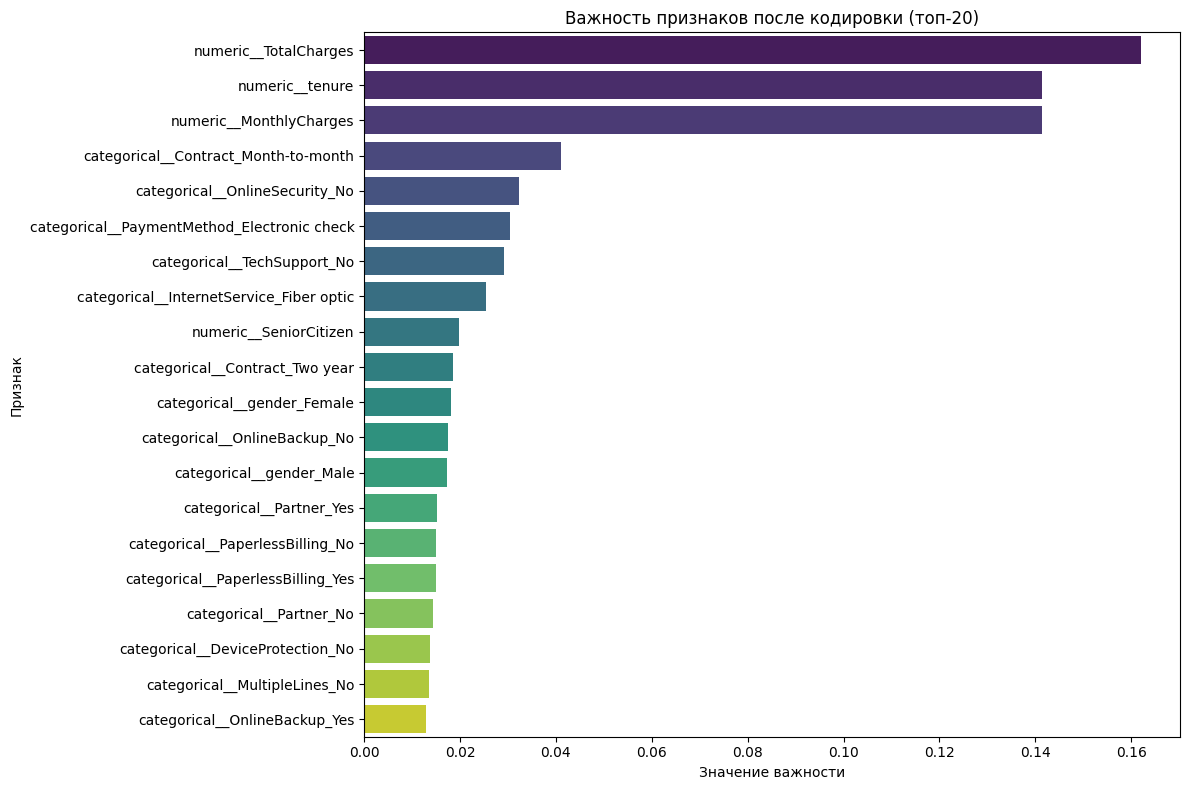

In [331]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)


plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='viridis')
plt.title('Важность признаков после кодировки (топ‑20)')
plt.xlabel('Значение важности')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

График важности признаков модели **XGBoost**

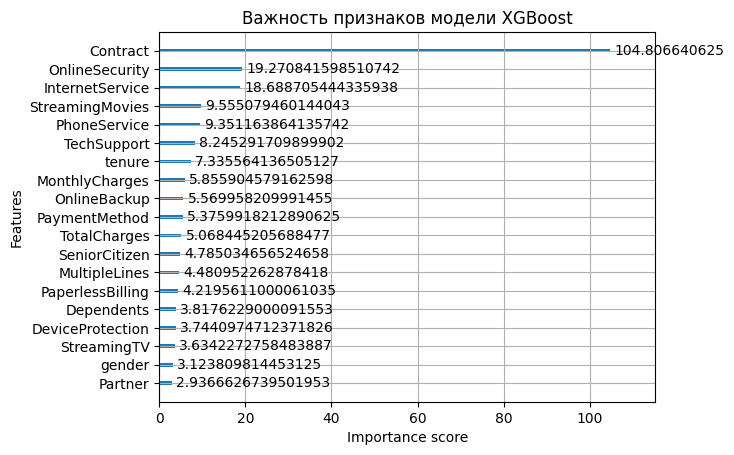

In [332]:
xgb.plot_importance(booster_xgb,title='Важность признаков модели XGBoost',importance_type='gain');

График важности признаков модели **LightBoost**

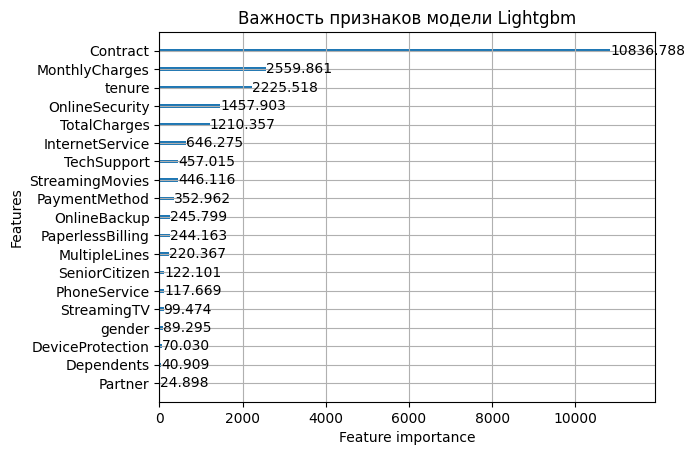

In [333]:
lgb.plot_importance(booster,importance_type='gain',title='Важность признаков модели Lightgbm');

График важности признаков модели **CatBoost**

/tmp/ipykernel_2291/2570618375.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clf_importance, x='importance', y='feature', palette='viridis')


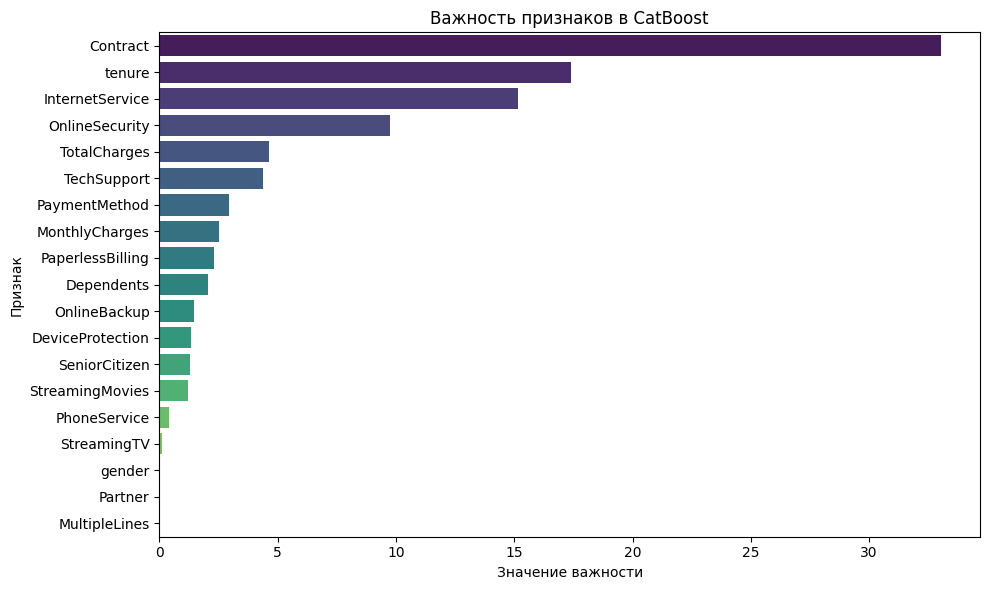

In [334]:
importance_clf = clf.get_feature_importance()


clf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importance_clf
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=clf_importance, x='importance', y='feature', palette='viridis')
plt.title('Важность признаков в CatBoost')
plt.xlabel('Значение важности')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

## 8. Фильтрация признаков

Удалите из датасета наименее важные на ваш взгляд признаки и обучите модели случайного леса и градиентного бустинга на полученном наборе данных. Как изменилось качество после фильтрации?

In [335]:
bad_importance = clf_importance[clf_importance['importance'] < 1]['feature'].tolist()

In [336]:
bad_importance += ['customerID','Churn']

In [337]:
bad_importance

['PhoneService',
 'StreamingTV',
 'gender',
 'Partner',
 'MultipleLines',
 'customerID',
 'Churn']

In [338]:
X = df.drop(columns=bad_importance)
y = df['Churn']

In [339]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape

((5634, 14), (1409, 14))

In [340]:
ohe_cols_new = []
numeric_cols_new = []

for col in X.columns:
  if X[col].dtype == 'object':
    ohe_cols_new.append(col)
  else:
    numeric_cols_new.append(col)

In [341]:
ohe_cols_new

['Dependents',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [342]:
numeric_cols_new

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [343]:
preprocessor_new = ColumnTransformer([
    ('categorical',OneHotEncoder(handle_unknown='ignore', sparse_output=False),ohe_cols_new),
    ('numeric','passthrough',numeric_cols_new)
])

X_train_processed = preprocessor_new.fit_transform(X_train)
X_test_processed = preprocessor_new.transform(X_test)

In [344]:
X_test_processed.shape

(1409, 33)

In [345]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

In [346]:
rf.fit(X_train_processed,y_train)


y_pred_rf = rf.predict(X_test_processed)# YOUR CODE HERE
y_proba_rf = rf.predict_proba(X_test_processed)[:,1]

accuracy = accuracy_score(y_test,y_pred_rf)
f1 = f1_score(y_test,y_pred_rf)
roc_auc = roc_auc_score(y_test,y_proba_rf)

print(f"accuracy:{accuracy:.2f},\nf1:{f1:.2f},\nroc_auc:{roc_auc:.2f}")

accuracy:0.79,
f1:0.56,
roc_auc:0.83


После удаления неинформативных признаков качество модели **RandomForest** практически не изменилась

In [347]:
train_pool = Pool(data=X_train, label=y_train, cat_features=ohe_cols_new)
eval_pool = Pool(data=X_test, label=y_test, cat_features=ohe_cols_new)

clf_new = CatBoostClassifier(
    depth=4,
    learning_rate=0.2,
    loss_function='Logloss',
    eval_metric='F1',
    auto_class_weights='Balanced',
    cat_features=ohe_cols_new
)

In [348]:
clf_new.fit(
    train_pool,
    eval_set=eval_pool,
    verbose=5,
    use_best_model=True,
    early_stopping_rounds=20
)

0:	learn: 0.7333166	test: 0.7618390	best: 0.7618390 (0)	total: 81.5ms	remaining: 1m 21s
5:	learn: 0.7720910	test: 0.7889357	best: 0.7904268 (3)	total: 566ms	remaining: 1m 33s
10:	learn: 0.7699067	test: 0.7842868	best: 0.7904268 (3)	total: 892ms	remaining: 1m 20s
15:	learn: 0.7751019	test: 0.7901157	best: 0.7904268 (3)	total: 1.22s	remaining: 1m 14s
20:	learn: 0.7779449	test: 0.7885867	best: 0.7933861 (16)	total: 1.54s	remaining: 1m 11s
25:	learn: 0.7799570	test: 0.7884060	best: 0.7933861 (16)	total: 1.85s	remaining: 1m 9s
30:	learn: 0.7860103	test: 0.7929532	best: 0.7933861 (16)	total: 2.06s	remaining: 1m 4s
35:	learn: 0.7857725	test: 0.7906431	best: 0.7941024 (31)	total: 2.36s	remaining: 1m 3s
40:	learn: 0.7869054	test: 0.7925948	best: 0.7944610 (39)	total: 2.69s	remaining: 1m 2s
45:	learn: 0.7874717	test: 0.7907257	best: 0.7944610 (39)	total: 2.95s	remaining: 1m 1s
50:	learn: 0.7887853	test: 0.7886762	best: 0.7944610 (39)	total: 3.23s	remaining: 1m
55:	learn: 0.7901470	test: 0.789755

CatBoostClassifier(auto_class_weights='Balanced', cat_features=['Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'], depth=4, eval_metric='F1', learning_rate=0.2, loss_function='Logloss')

In [349]:
clf_pred = clf_new.predict(X_test)
clf_pred_proba = clf_new.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, clf_pred))
print("F1:", f1_score(y_test, clf_pred))
print("ROC-AUC:", roc_auc_score(y_test, clf_pred_proba))

Accuracy: 0.7459190915542938
F1: 0.6398390342052314
ROC-AUC: 0.8619626424586211


Качество модели CatBoost так же практиески не изменилось

In [350]:
for col in ohe_cols_new:
  X[col]=le.fit_transform(X[col])

In [351]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [352]:
train_lgb = Dataset(
    X_train,
    y_train,
    categorical_feature=ohe_cols_new,
    free_raw_data=False
)

valid_lgb = Dataset(
    X_test,
    y_test,
    categorical_feature=ohe_cols_new,
    free_raw_data=False
)

In [353]:
params = {
    'objective': 'binary',
    'is_unbalance': True,
    'learning_rate': 0.1
}


booster_lgb = train(
    params,
    train_set=train_lgb,
    valid_sets=(valid_lgb,),
    num_boost_round=20

)


lgb_pred_new = booster_lgb.predict(X_test)
y_pred_lgb_new = (lgb_pred_new > 0.5).astype(int)

[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.100405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 624
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265531 -> initscore=-1.017418
[LightGBM] [Info] Start training from score -1.017418


In [354]:
accuracy = accuracy_score(y_test,y_pred_lgb_new)
f1 = f1_score(y_test,y_pred_lgb_new)
roc_auc = roc_auc_score(y_test,lgb_pred_new)

print(f"accuracy:{accuracy:.2f},\nf1:{f1:.2f},\nroc_auc:{roc_auc:.2f}")

accuracy:0.76,
f1:0.64,
roc_auc:0.86


In [355]:
for col in ohe_cols_new:
  X[col] = X[col].astype('category')

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [356]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 2142 to 860
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     5634 non-null   int64   
 1   Dependents        5634 non-null   category
 2   tenure            5634 non-null   int64   
 3   InternetService   5634 non-null   category
 4   OnlineSecurity    5634 non-null   category
 5   OnlineBackup      5634 non-null   category
 6   DeviceProtection  5634 non-null   category
 7   TechSupport       5634 non-null   category
 8   StreamingMovies   5634 non-null   category
 9   Contract          5634 non-null   category
 10  PaperlessBilling  5634 non-null   category
 11  PaymentMethod     5634 non-null   category
 12  MonthlyCharges    5634 non-null   float64 
 13  TotalCharges      5624 non-null   float64 
dtypes: category(10), float64(2), int64(2)
memory usage: 276.4 KB


In [357]:
xgb_train = xgb.DMatrix(
    X_train,
    label=y_train,
    nthread=-1,
    enable_categorical=True
)

xgb_test = xgb.DMatrix(
    X_test,
    label=y_test,
    nthread=-1,
    enable_categorical=True
)

In [358]:
n_negative = (y_train==0).sum()
n_positive = (y_train==1).sum()
scale_pos_weight = n_negative / n_positive

params = {
    'objective':'binary:logistic',
    'scale_pos_weight': scale_pos_weight,
    'eval_metric':'logloss',
    'seed': 42
}

booster_xgb=xgb.train(
    params,
    dtrain=xgb_train,
    num_boost_round=30,
    evals=[(xgb_train,'dtrain'),(xgb_test,'dtest')],
    early_stopping_rounds=20,
    verbose_eval=5
)

[0]	dtrain-logloss:0.59435	dtest-logloss:0.59961
[5]	dtrain-logloss:0.45169	dtest-logloss:0.48348
[10]	dtrain-logloss:0.41495	dtest-logloss:0.46575
[15]	dtrain-logloss:0.39108	dtest-logloss:0.46078
[20]	dtrain-logloss:0.37016	dtest-logloss:0.45781
[25]	dtrain-logloss:0.35632	dtest-logloss:0.46025
[29]	dtrain-logloss:0.34528	dtest-logloss:0.46007


In [359]:
y_proba_xgb = booster_xgb.predict(xgb_test)
y_pred_xgb = (y_proba_xgb > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

Accuracy: 0.7771469127040455
F1: 0.6487695749440716
ROC-AUC: 0.8524628132536979


## 9. Выводы
- Сравните качество моделей
- Сделайте вывод, какая модель лучше справилась
- Подумайте, почему именно так

In [397]:
results = {
    'Модель': ['RandomForest', 'CatBoostClassifier', 'LightGBM', 'XGBoost'],
    'Accuracy': [0.79, 0.74, 0.76, 0.78],
    'F1-Score': [0.56, 0.64, 0.64, 0.65],
    'ROC-AUC': [0.73, 0.86, 0.86, 0.85],

}


df_results = pd.DataFrame(results)

# Сортировка по главной метрике (например, ROC-AUC)
df_results = df_results.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

display(df_results)

,Модель,Accuracy,F1-Score,ROC-AUC
0,CatBoostClassifier,0.74,0.64,0.86
1,LightGBM,0.76,0.64,0.86
2,XGBoost,0.78,0.65,0.85
3,RandomForest,0.79,0.56,0.73


Вывод:

Лучшей моделью оказалась **XGBoost**, с качествами метрик : **Accuracy: 0.78**,
**F1: 0.65**,
**ROC-AUC: 0.85**. Удаление наименее важных признаков практически не повлияло на качество моделей.Вероятно, данные признаки уже имели минимальный вклад в принятие решений и фактически игнорировались алгоритмами.Это особенно характерно для ансамблевых методов,которые способны самостоятельно снижать влияние слабых признаков